# Nested Sampling in the Gaussian Special Case

This notebook studies the performance of **nested sampling** for approximating the **marginal likelihood** in the Gaussian special case where:

- $\Sigma = I_d$,
- the empirical mean satisfies $\bar y = 0$.

The goal is not only to run the algorithm, but also to understand:

1. how the algorithm works step by step,
2. how the estimate of the evidence is built,
3. how performance changes with the number of live points,
4. how difficulty scales with the dimension $d$ and the sample size $n$.

We proceed from the most intuitive diagnostics to broader performance comparisons.

## 1. Imports and plotting style

We begin by importing the numerical tools used throughout the notebook.

- `numpy` for simulation and linear algebra,
- `scipy.stats.chi2` for the exact truncated radial sampling,
- `scipy.special.logsumexp` for stable computations in log-scale,
- `matplotlib` for the visual diagnostics.

All calculations are done in **log-space** whenever possible to avoid numerical underflow.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2
from scipy.special import logsumexp

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 2. Data generation under the special case $\bar y = 0$

In the special case studied in the report, the likelihood simplifies to a radial function of $\theta$.  
To match this setting exactly, we simulate Gaussian data and then **force the empirical mean to be exactly zero** by centering the sample.

This is useful because the closed-form marginal likelihood becomes available, which gives us a ground truth for comparison.

In [2]:
def simulate_centered_data(n, d, seed=None):
    """
    Simulate y_1, ..., y_n in R^d and enforce the empirical mean to be exactly 0.
    """
    rng = np.random.default_rng(seed)
    Y = rng.normal(size=(n, d))
    Y = Y - Y.mean(axis=0, keepdims=True)
    return Y

## 3. Closed-form quantities: $\log C$ and the true log-evidence

In the special case, the likelihood can be written as

$$
L(\theta) = C \exp\left(-\frac{n}{2}\|\theta\|^2\right).
$$

So the key constant is $C$, or more precisely $\log C$.

We also have an exact expression for the marginal likelihood $p(y)$, which we use as the benchmark when assessing the quality of nested sampling.

In [3]:
def compute_logC(Y):
    """
    Compute log C where
    L(theta) = C * exp(-(n/2) ||theta||^2).
    """
    n, d = Y.shape
    sumsq = np.sum(Y**2)
    return -0.5 * n * d * np.log(2 * np.pi) - 0.5 * sumsq


def true_log_evidence(Y):
    """
    In the special case ybar = 0 and Sigma = I_d,
    log p(y) = -(nd/2) log(2pi) - (d/2) log(n+1) - 1/2 sum ||y_i||^2.
    """
    n, d = Y.shape
    sumsq = np.sum(Y**2)
    return -0.5 * n * d * np.log(2 * np.pi) - 0.5 * d * np.log(n + 1) - 0.5 * sumsq

## 4. Likelihood as a function of $\theta$

Because we are in the simplified Gaussian setting, evaluating the likelihood is especially easy:

$$
Z = \int L(\theta)\,\pi(\theta)\,d\theta
$$

This means that the likelihood depends only on the radius $\|\theta\|$, so the likelihood contours are spheres.

In [4]:
def loglik_theta(theta, logC, n):
    """
    log L(theta) = logC - (n/2)||theta||^2
    """
    return logC - 0.5 * n * np.dot(theta, theta)

## 5. Exact constrained sampling from the prior

This is the crucial simplification of the special case.

At each nested sampling iteration, we must replace the worst live point by a new point sampled from

$$
\pi(\theta \mid L(\theta) > L_{\min}).
$$

In our model,

$$
L(\theta) > l
\quad \Longleftrightarrow \quad
\|\theta\|^2 < r_l^2.
$$

So the constrained prior becomes a standard Gaussian prior restricted to a ball.

To sample exactly:

1. sample the radius squared from a truncated $\chi^2_d$,
2. sample a direction uniformly on the sphere,
3. combine them as $\theta = R U$.

This avoids using MCMC and makes the implementation exact in this special setting.

In [16]:
def sample_uniform_sphere(d, rng):
    """
    Sample a direction uniformly on the unit sphere in R^d.
    """
    z = rng.normal(size=d)
    norm_z = np.linalg.norm(z)
    while norm_z == 0:
        z = rng.normal(size=d)
        norm_z = np.linalg.norm(z)
    return z / norm_z


def sample_prior_constrained(logL_min, logC, n, d, rng, tol=1e-14):
    """
    Exact sample from prior N_d(0, I_d) conditional on L(theta) > L_min.

    In the Gaussian special case:
        log L(theta) = logC - (n/2)||theta||^2
    so the constraint becomes:
        ||theta||^2 < r^2
    with
        r^2 = (2/n)(logC - logL_min).
    """
    r2 = (2.0 / n) * (logC - logL_min)

    # Numerical clipping
    if r2 < 0:
        if r2 > -tol:
            r2 = 0.0
        else:
            raise ValueError(f"Negative r2 encountered: {r2}")

    # If the admissible region is numerically tiny,
    # return theta = 0, which is the maximum-likelihood point.
    if r2 <= tol:
        return np.zeros(d)

    cdf_upper = chi2.cdf(r2, df=d)

    # If the truncated chi-square mass is numerically zero,
    # again fall back to the center.
    if cdf_upper <= tol:
        return np.zeros(d)

    u = rng.uniform(0.0, cdf_upper)
    s = chi2.ppf(u, df=d)

    # Safety in case ppf returns something tiny/negative numerically
    s = max(s, 0.0)

    radius = np.sqrt(s)
    direction = sample_uniform_sphere(d, rng)
    theta = radius * direction
    return theta

## 6. Nested sampling implementation

We now implement nested sampling itself.

At a high level, each iteration does the following:

1. identify the live point with the smallest likelihood,
2. remove it and record its likelihood,
3. shrink the prior mass,
4. add its contribution to the evidence,
5. replace it with a new constrained sample.

We also optionally store the **running estimate** of the evidence, which is useful for convergence plots.

In [17]:
def nested_sampling_gaussian_special(
    Y,
    N_live=100,
    max_iter=1000,
    seed=None,
    use_random_shrinkage=True,
    return_path=False,
    stop_tol=1e-10
):
    rng = np.random.default_rng(seed)
    n, d = Y.shape
    logC = compute_logC(Y)

    live_thetas = rng.normal(size=(N_live, d))
    live_logLs = np.array([loglik_theta(theta, logC, n) for theta in live_thetas])

    X_prev = 1.0
    log_terms = []
    dead_logLs = []
    Xs = [X_prev]
    logZ_partial = []

    for _ in range(max_iter):
        worst_idx = np.argmin(live_logLs)
        logL_t = live_logLs[worst_idx]
        dead_logLs.append(logL_t)

        if use_random_shrinkage:
            T_t = rng.beta(N_live, 1)
        else:
            T_t = np.exp(-1.0 / N_live)

        X_t = X_prev * T_t
        w_t = X_prev - X_t

        log_terms.append(np.log(w_t) + logL_t)

        logZ_now = logsumexp(log_terms)
        logZ_partial.append(logZ_now)

        # Termination criterion:
        # upper bound on remaining live contribution
        log_remaining_upper = np.log(X_t) + np.max(live_logLs)

        # Stop if the remaining contribution is negligible
        if log_remaining_upper - logZ_now < np.log(stop_tol):
            X_prev = X_t
            Xs.append(X_prev)
            break

        new_theta = sample_prior_constrained(logL_t, logC, n, d, rng)
        new_logL = loglik_theta(new_theta, logC, n)

        live_thetas[worst_idx] = new_theta
        live_logLs[worst_idx] = new_logL

        X_prev = X_t
        Xs.append(X_prev)

    log_live_meanL = logsumexp(live_logLs) - np.log(N_live)
    logZ_live = np.log(X_prev) + log_live_meanL

    logZ_hat_no_live = logsumexp(log_terms)
    logZ_hat = logsumexp([logZ_hat_no_live, logZ_live])

    out = {
        "logZ_hat": logZ_hat,
        "logZ_hat_no_live": logZ_hat_no_live,
        "dead_logLs": np.array(dead_logLs),
        "Xs": np.array(Xs),
        "live_logLs": live_logLs.copy(),
    }

    if return_path:
        out["logZ_partial"] = np.array(logZ_partial)

    return out

## 7. Helper functions for repeated experiments

To assess performance, we do not want to rely on a single run.

So for each value of $\N_{\text{live}}$, and later for each pair $(n,d)$, we repeat nested sampling many times and summarize:

- the mean estimate,
- the standard deviation,
- the bias,
- the RMSE.

This lets us distinguish between **systematic error** and **random variability**.

In [7]:
def assess_ns_performance_single_dataset(
    Y,
    N_live_list=(20, 50, 100, 200),
    n_rep=100,
    max_iter=1000,
    seed=12345
):
    true_logZ = true_log_evidence(Y)
    rng = np.random.default_rng(seed)
    results = {}

    for N_live in N_live_list:
        estimates = []

        for _ in range(n_rep):
            run_seed = int(rng.integers(0, 10**9))
            out = nested_sampling_gaussian_special(
                Y,
                N_live=N_live,
                max_iter=max_iter,
                seed=run_seed,
                use_random_shrinkage=True
            )
            estimates.append(out["logZ_hat"])

        estimates = np.array(estimates)
        errors = estimates - true_logZ

        results[N_live] = {
            "true_logZ": true_logZ,
            "mean_logZ_hat": np.mean(estimates),
            "std_logZ_hat": np.std(estimates, ddof=1),
            "bias_logZ": np.mean(errors),
            "rmse_logZ": np.sqrt(np.mean(errors**2)),
            "estimates": estimates,
            "errors": errors,
        }

    return results


def assess_ns_grid(
    n_list=(20, 50),
    d_list=(2, 5, 10, 20),
    N_live_list=(20, 50, 100, 200),
    n_datasets=20,
    n_rep=30,
    max_iter=1000,
    seed=1234
):
    rng = np.random.default_rng(seed)
    summary = {}

    for n in n_list:
        for d in d_list:
            for N_live in N_live_list:
                all_estimates = []
                all_true = []

                for _ in range(n_datasets):
                    data_seed = int(rng.integers(0, 10**9))
                    Y = simulate_centered_data(n, d, seed=data_seed)
                    logZ_true = true_log_evidence(Y)

                    for _ in range(n_rep):
                        run_seed = int(rng.integers(0, 10**9))
                        out = nested_sampling_gaussian_special(
                            Y,
                            N_live=N_live,
                            max_iter=max_iter,
                            seed=run_seed,
                            use_random_shrinkage=True
                        )
                        all_estimates.append(out["logZ_hat"])
                        all_true.append(logZ_true)

                all_estimates = np.array(all_estimates)
                all_true = np.array(all_true)
                errors = all_estimates - all_true

                summary[(n, d, N_live)] = {
                    "mean_estimate": np.mean(all_estimates),
                    "mean_true": np.mean(all_true),
                    "bias": np.mean(errors),
                    "abs_bias": np.abs(np.mean(errors)),
                    "std": np.std(all_estimates, ddof=1),
                    "rmse": np.sqrt(np.mean(errors**2)),
                    "n_obs": len(all_estimates),
                    "errors": errors,
                    "estimates": all_estimates,
                    "true_vals": all_true,
                }

    return summary

## 8. Plotting functions

We now define the plotting utilities.

The order of the figures will be the following:

1. one-run convergence diagnostics,
2. repeated-run variability on one dataset,
3. RMSE, bias and standard deviation on one dataset,
4. scaling with dimension,
5. heatmap summary,
6. scaling with sample size.

This gives a natural progression from intuition to performance evaluation.

In [8]:
def plot_convergence_example(Y, N_live=100, max_iter=1000, seed=1):
    true_val = true_log_evidence(Y)
    out = nested_sampling_gaussian_special(
        Y,
        N_live=N_live,
        max_iter=max_iter,
        seed=seed,
        use_random_shrinkage=True,
        return_path=True
    )

    plt.figure()
    plt.plot(out["logZ_partial"], label="Running estimate")
    plt.axhline(true_val, linestyle="--", linewidth=1.5, label="True log-evidence")
    plt.xlabel("Iteration")
    plt.ylabel("log-evidence estimate")
    plt.title(f"Convergence of one nested sampling run (N_live={N_live})")
    plt.legend()
    plt.show()


def plot_logX_trajectory(Y, N_live=100, max_iter=1000, seed=1):
    out = nested_sampling_gaussian_special(
        Y,
        N_live=N_live,
        max_iter=max_iter,
        seed=seed,
        use_random_shrinkage=True
    )

    Xs = out["Xs"][1:]
    plt.figure()
    plt.plot(-np.log(Xs))
    plt.xlabel("Iteration")
    plt.ylabel(r"$-\log X_t$")
    plt.title(f"Prior mass shrinkage (N_live={N_live})")
    plt.show()


def plot_boxplots(results):
    N_vals = sorted(results.keys())
    data = [results[N]["estimates"] for N in N_vals]
    true_val = results[N_vals[0]]["true_logZ"]

    plt.figure()
    plt.boxplot(data, labels=[str(N) for N in N_vals])
    plt.axhline(true_val, linestyle="--", linewidth=1.5, label="True log-evidence")
    plt.xlabel("Number of live points")
    plt.ylabel("Estimated log-evidence")
    plt.title("Nested sampling estimates across repetitions")
    plt.legend()
    plt.show()


def plot_rmse(results):
    N_vals = sorted(results.keys())
    rmse_vals = [results[N]["rmse_logZ"] for N in N_vals]

    plt.figure()
    plt.plot(N_vals, rmse_vals, marker="o")
    plt.xlabel("Number of live points")
    plt.ylabel("RMSE of log-evidence")
    plt.title("RMSE vs number of live points")
    plt.show()


def plot_bias_std(results):
    N_vals = sorted(results.keys())
    bias_vals = [results[N]["bias_logZ"] for N in N_vals]
    std_vals = [results[N]["std_logZ_hat"] for N in N_vals]

    plt.figure()
    plt.plot(N_vals, bias_vals, marker="o", label="Bias")
    plt.plot(N_vals, std_vals, marker="s", label="Std. dev.")
    plt.xlabel("Number of live points")
    plt.ylabel("Value")
    plt.title("Bias and standard deviation")
    plt.legend()
    plt.show()


def plot_rmse_vs_N_for_each_d(summary, n_fixed, d_list, N_live_list):
    plt.figure()
    for d in d_list:
        vals = [summary[(n_fixed, d, N)]["rmse"] for N in N_live_list]
        plt.plot(N_live_list, vals, marker="o", label=f"d={d}")

    plt.xlabel("Number of live points")
    plt.ylabel("RMSE")
    plt.title(f"RMSE vs N_live for n={n_fixed}")
    plt.legend()
    plt.show()


def plot_heatmap_rmse(summary, n_fixed, d_list, N_live_list):
    M = np.zeros((len(d_list), len(N_live_list)))
    for i, d in enumerate(d_list):
        for j, N in enumerate(N_live_list):
            M[i, j] = summary[(n_fixed, d, N)]["rmse"]

    plt.figure()
    im = plt.imshow(M, aspect="auto", origin="lower")
    plt.colorbar(im, label="RMSE")
    plt.xticks(range(len(N_live_list)), N_live_list)
    plt.yticks(range(len(d_list)), d_list)
    plt.xlabel("N_live")
    plt.ylabel("Dimension d")
    plt.title(f"RMSE heatmap for n={n_fixed}")
    plt.show()


def plot_std_heatmap(summary, n_fixed, d_list, N_live_list):
    M = np.zeros((len(d_list), len(N_live_list)))
    for i, d in enumerate(d_list):
        for j, N in enumerate(N_live_list):
            M[i, j] = summary[(n_fixed, d, N)]["std"]

    plt.figure()
    im = plt.imshow(M, aspect="auto", origin="lower")
    plt.colorbar(im, label="Std. dev. of estimates")
    plt.xticks(range(len(N_live_list)), N_live_list)
    plt.yticks(range(len(d_list)), d_list)
    plt.xlabel("N_live")
    plt.ylabel("Dimension d")
    plt.title(f"Std. dev. heatmap for n={n_fixed}")
    plt.show()


def plot_rmse_vs_N_for_each_n(summary, d_fixed, n_list, N_live_list):
    plt.figure()
    for n in n_list:
        vals = [summary[(n, d_fixed, N)]["rmse"] for N in N_live_list]
        plt.plot(N_live_list, vals, marker="o", label=f"n={n}")

    plt.xlabel("Number of live points")
    plt.ylabel("RMSE")
    plt.title(f"RMSE vs N_live for d={d_fixed}")
    plt.legend()
    plt.show()

## 9. A first concrete example

We start with one illustrative configuration.

This part is useful because it anchors the rest of the notebook in a concrete case before we move to large comparison grids.

In [9]:
# Example configuration
n = 20
d = 5
Y = simulate_centered_data(n, d, seed=42)

logZ_true = true_log_evidence(Y)
print(f"True log-evidence: {logZ_true:.6f}")
print(f"logC: {compute_logC(Y):.6f}")

True log-evidence: -128.117884
logC: -120.506578


## 10. First diagnostic: how one nested sampling run evolves

Before averaging over many repetitions, it is useful to look at a **single run**.

We plot:

- the running estimate of the log-evidence,
- the true log-evidence as a benchmark,
- the trajectory of $-\log X_t$, which reflects the progressive shrinkage of the prior mass.

These plots help us understand the mechanics of the algorithm before we evaluate its statistical accuracy.

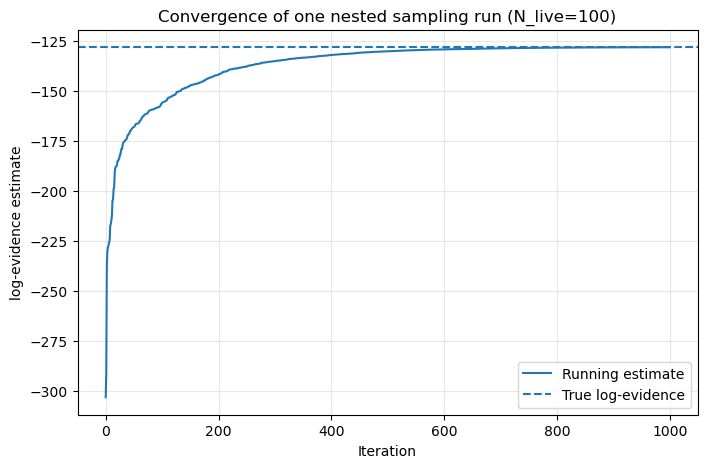

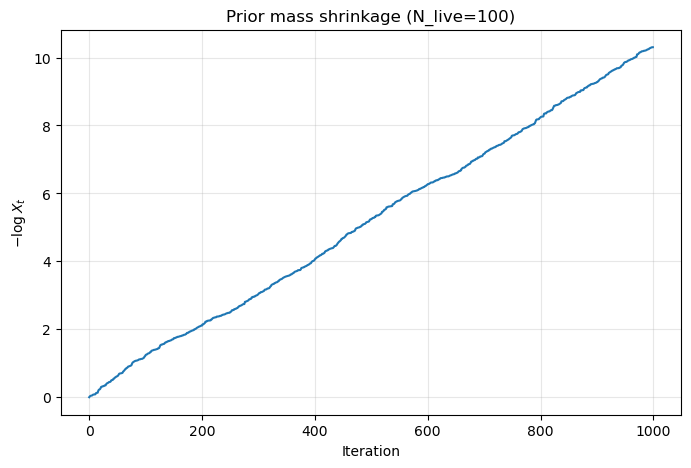

In [10]:
plot_convergence_example(Y, N_live=100, max_iter=1000, seed=1)
plot_logX_trajectory(Y, N_live=100, max_iter=1000, seed=1)

## 11. Repeated runs on one fixed dataset

Now we keep the dataset fixed and repeat nested sampling many times.

This isolates the randomness coming from the nested sampling algorithm itself.  
It allows us to answer:

- how variable are the estimates?
- does increasing $\N_{\text{live}}$ reduce dispersion?
- is there visible bias?

Around 1min-1min30

In [11]:
results_single = assess_ns_performance_single_dataset(
    Y,
    N_live_list=(20, 50, 100, 200, 500),
    n_rep=100,
    max_iter=1000,
    seed=2024
)

### Visualizing the distribution of estimates

The boxplots show the spread of the estimates across repetitions for different values of $N_{\text{live}}$.

The dashed horizontal line is the true log-evidence.  
Ideally, the boxes should become tighter and remain centered around the truth as $N_{\text{live}}$ increases.

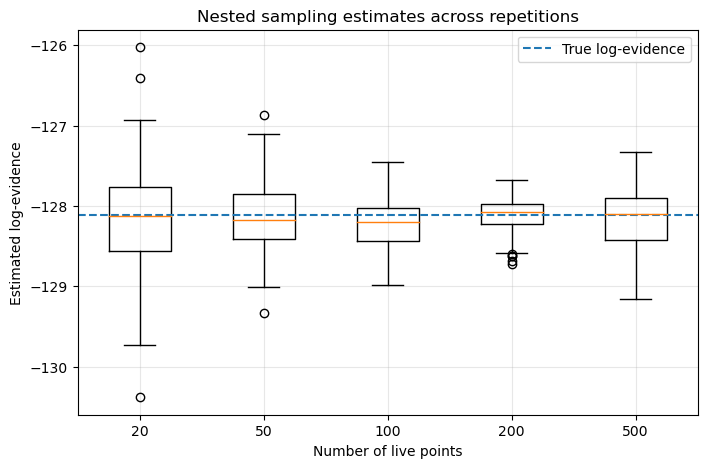

In [12]:
plot_boxplots(results_single)

### RMSE, bias and variability

We now summarize the repeated-run performance with three complementary indicators:

- **RMSE**: overall accuracy,
- **bias**: systematic deviation from the truth,
- **standard deviation**: Monte Carlo variability.

This helps distinguish whether errors come mostly from bias or from randomness.

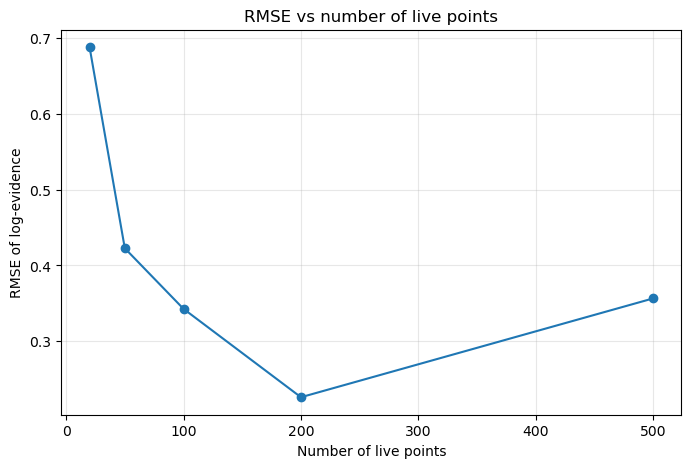

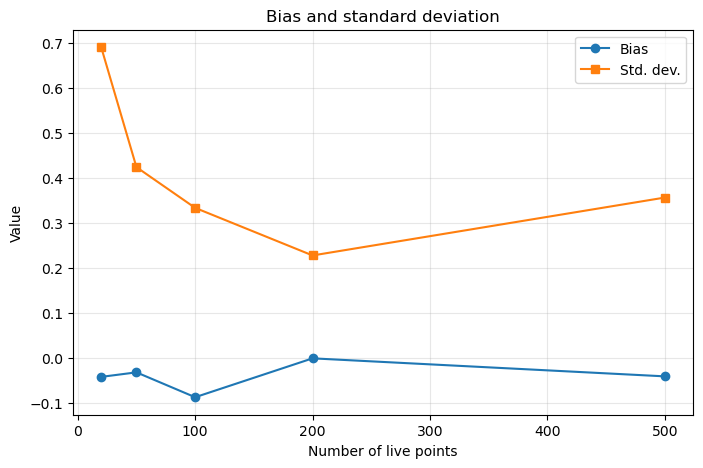

In [13]:
plot_rmse(results_single)
plot_bias_std(results_single)

### Numerical summary for the fixed dataset

The table below makes the previous plots easier to comment in a report.

In [14]:
for N_live, res in results_single.items():
    print(
        f"N_live={N_live:3d} | "
        f"mean={res['mean_logZ_hat']:.6f} | "
        f"std={res['std_logZ_hat']:.6f} | "
        f"bias={res['bias_logZ']:.6f} | "
        f"rmse={res['rmse_logZ']:.6f}"
    )

N_live= 20 | mean=-128.160175 | std=0.689979 | bias=-0.042291 | rmse=0.687822
N_live= 50 | mean=-128.150139 | std=0.423590 | bias=-0.032255 | rmse=0.422699
N_live=100 | mean=-128.205388 | std=0.333109 | bias=-0.087504 | rmse=0.342796
N_live=200 | mean=-128.119025 | std=0.227421 | bias=-0.001141 | rmse=0.226284
N_live=500 | mean=-128.159042 | std=0.356017 | bias=-0.041158 | rmse=0.356616


## 12. Scaling with dimension

So far, we have assessed performance on one single problem.  
But nested sampling difficulty depends strongly on the geometry of the space, and dimension is a natural driver of difficulty.

We therefore compare several dimensions $d$, while keeping $n$ fixed.

To make the conclusions more robust, we now average over:

- several independently generated datasets,
- several nested sampling runs for each dataset.

Be careful it is a bit long ...

In [ ]:
summary_dim = assess_ns_grid(
    n_list=(20,),
    d_list=(2, 5, 10, 20),
    N_live_list=(20, 50, 100, 200),
    n_datasets=20,
    n_rep=30,
    max_iter=1000,
    seed=1234
)

### RMSE as a function of $\N_{\text{live}}$, one curve per dimension

This is one of the most informative plots in the notebook.

It answers the question:

> How much does performance improve when we increase the number of live points, and how does this depend on dimension?

In [ ]:
plot_rmse_vs_N_for_each_d(
    summary_dim,
    n_fixed=20,
    d_list=(2, 5, 10, 20),
    N_live_list=(20, 50, 100, 200)
)

### Heatmaps: performance landscape across $\N_{\text{live}}$

Heatmaps provide a compact global view.

- The RMSE heatmap shows overall estimation accuracy.
- The standard deviation heatmap shows how much Monte Carlo variability remains.

These figures are useful in a report because they make the scaling behavior visible at a glance.

In [ ]:
plot_heatmap_rmse(
    summary_dim,
    n_fixed=20,
    d_list=(2, 5, 10, 20),
    N_live_list=(20, 50, 100, 200)
)

plot_std_heatmap(
    summary_dim,
    n_fixed=20,
    d_list=(2, 5, 10, 20),
    N_live_list=(20, 50, 100, 200)
)

## 13. Scaling with sample size

Dimension is not the only source of difficulty.  
The sample size $n $ also matters, because the likelihood becomes more concentrated as $n $ increases.

We now fix the dimension and vary $n $, again averaging over several datasets and repetitions.

In [ ]:
summary_n = assess_ns_grid(
    n_list=(10, 20, 50, 100),
    d_list=(5,),
    N_live_list=(20, 50, 100, 200),
    n_datasets=20,
    n_rep=30,
    max_iter=1000,
    seed=5678
)

### RMSE as a function of $\N_{\text{live}}$, one curve per sample size

This figure helps us see whether larger values of $n$ require more live points for stable and accurate estimation.

In [ ]:
plot_rmse_vs_N_for_each_n(
    summary_n,
    d_fixed=5,
    n_list=(10, 20, 50, 100),
    N_live_list=(20, 50, 100, 200)
)

## 15. Conclusion

This notebook was organized in a deliberate order:

1. understand the model,
2. understand the constrained sampler,
3. inspect one nested sampling run,
4. assess repeated-run performance on one dataset,
5. study scaling with dimension,
6. study scaling with sample size.

This progression makes it easier to interpret the figures and to connect the implementation back to the theoretical structure of nested sampling.